In [1]:
import numpy as np
from sedona.spark import SedonaContext
import os
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import pyspark.sql.functions as f

In [2]:
%%capture
bucket_name = os.environ.get("SEDONA_SOURCE_BUCKET", "apache-sedona-book")

config = SedonaContext.builder()

sedona = SedonaContext.create(config.getOrCreate())

sedona.sparkContext.setLogLevel("ERROR")

sc = sedona.sparkContext
sedona.sparkContext.setCheckpointDir("checkpoint")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/11/23 20:42:01 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/11/23 20:42:04 WARN UDTRegistration: Cannot register UDT for org.geotools.coverage.grid.GridCoverage2D, which is already registered.
25/11/23 20:42:04 WARN SimpleFunctionRegistry: The function rs_union_aggr replaced a previously registered function.
25/11/23 20:42:04 WARN UDTRegistration: Cannot register UDT for org.locationtech.jts.geom.Geometry, which is already registered.
25/11/23 20:42:04 WARN UDTRegistration: Cannot register UDT for org.apache.sedona.common.S2Geography.Geography, which is already registered.
25/11/23 20:42:04 WARN UDTRegistration: Cannot register UDT for org.locationtech.jts.index.SpatialIndex, which is already registered.
25/11/23 20:42:04 WARN SimpleFunctionRegistry: The function st_envelop

# Density Points location

In [3]:
density_points = pd.read_csv("source_data/density_points/density_points.csv").reset_index()

Text(0.5, 1.0, 'Point Locations')

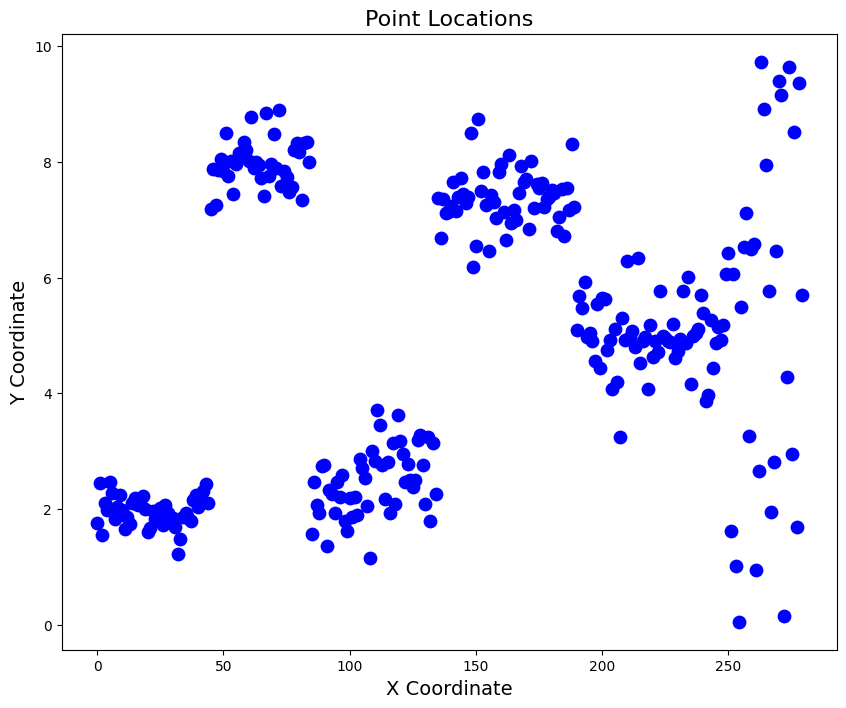

In [4]:
plt.figure(figsize=(10, 8))

plt.scatter(
    np.array(density_points)[:, 0], 
    np.array(density_points)[:, 1],
    s=80, 
    color="blue"
)
plt.xlabel('X Coordinate', fontsize=14)
plt.ylabel('Y Coordinate', fontsize=14)
plt.title('Point Locations', fontsize=16)

## DBScan parameters

In [5]:
epsilon = 0.5
min_pts = 10

## Example point Vizualization

In [6]:
index = 10

x, y = density_points[density_points["index"] == index][["x", "y"]].values.tolist()[0]

spatial_df = sedona.createDataFrame(density_points).\
    selectExpr("index", "ST_Point(x, y) AS geom")

spatial_df.createOrReplaceTempView("points")

example_point = spatial_df.\
    where(f"index == {index}").\
    selectExpr("index", f"ST_Buffer(geom, {epsilon}) AS geom")

neighbors = example_point.alias("e").\
    join(spatial_df.alias("s"), f.expr("ST_Intersects(s.geom, e.geom)")).\
    selectExpr("s.index", "s.geom")

In [7]:
## example point is core point
neighbors.count() > min_pts

True

In [8]:
example = spatial_df.join(neighbors, "index", "leftanti").\
    where(f"index!={index}").\
    withColumn("type", f.lit("normal")).\
    withColumn("opacity", f.lit(0.5)).\
    unionAll(example_point.withColumn("type", f.lit("example_point_buffer")).withColumn("opacity", f.lit(0.5))).\
    unionAll(neighbors.withColumn("type", f.lit("neighbors")).withColumn("opacity", f.lit(0.5))).\
    unionAll(spatial_df.where(f"index={index}").withColumn("type", f.lit("example_point")).withColumn("opacity", f.lit(0.5)))

gdf = gpd.GeoDataFrame(example.toPandas(), geometry="geom")

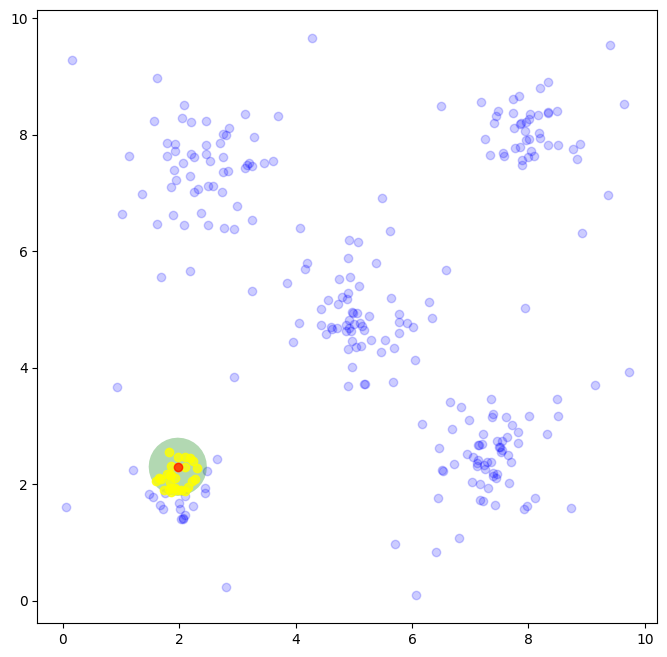

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

geom_types = {
    "normal": ["blue", 0.2],
    "example_point_buffer": ["green", 0.3],
    "neighbors": ["yellow", 0.8],
    "example_point": ["red", 0.7]
}

for geom_type, properties in geom_types.items():
    gdf[gdf["type"] == geom_type].plot(alpha=properties[1], ax=ax, color=properties[0])

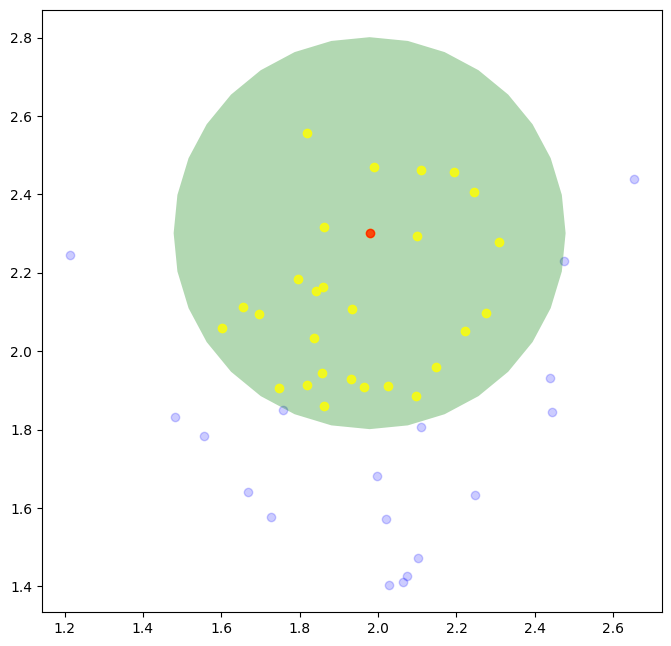

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))


for geom_type, properties in geom_types.items():
    gdf[
        (gdf["type"] == geom_type) &
        (gdf["geom"].centroid.x < x+1) &
        (gdf["geom"].centroid.y < y+1) &
        (gdf["geom"].centroid.y > y-1) &
        (gdf["geom"].centroid.x > x-1)
    ].plot(alpha=properties[1], ax=ax, color=properties[0])

## Sedona DBScan algorithm

In [11]:
sedona.table("points").printSchema()

root
 |-- index: long (nullable = true)
 |-- geom: geometry (nullable = true)



In [12]:
dbscan_df = sedona.sql(
    """
    SELECT
        index,
        geom AS geom,
        ST_DBSCAN(geom, 0.5, 10, False) AS scan
    FROM points
    """
)

result = dbscan_df.select("scan.*", "index", "geom")

In [13]:
result.printSchema()

root
 |-- isCore: boolean (nullable = true)
 |-- cluster: long (nullable = true)
 |-- index: long (nullable = true)
 |-- geom: geometry (nullable = true)



In [14]:
result.cache().count()

280

In [15]:
unique_labels = [el[0] for el in result.selectExpr("cluster").distinct().collect()]

points = result.\
    selectExpr("ST_X(geom) AS x", "ST_Y(geom) AS y", "cluster").\
    toPandas()

## Vizualize DBScan result

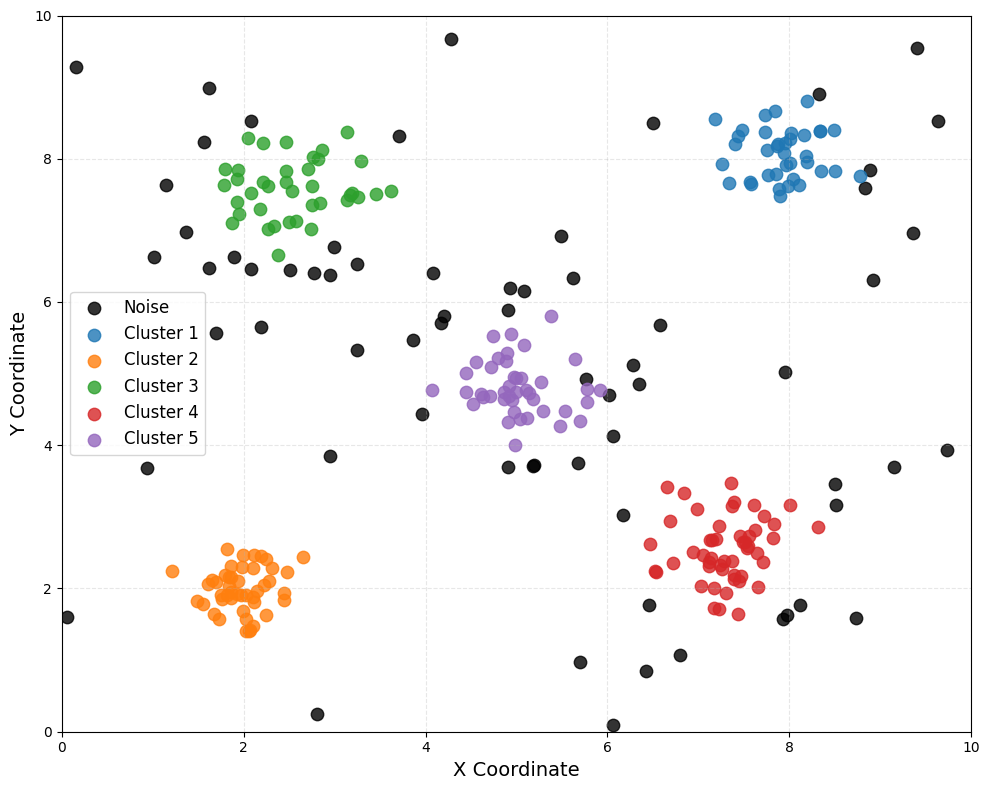

In [16]:
colors = ['black', '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

plt.figure(figsize=(10, 8))
for index, (label, color) in enumerate(zip(sorted(unique_labels), colors)):
    plt.scatter(
        points[points["cluster"] == label]["x"],
        points[points["cluster"] == label]["y"],
        s=80,
        color=color,
        alpha=0.8,
        label=f'Cluster {index}' if label != -1 else 'Noise'
    )

plt.xlabel('X Coordinate', fontsize=14)
plt.ylabel('Y Coordinate', fontsize=14)
plt.xlim(0, 10)
plt.ylim(0, 10)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()